# Deforestación Perú — Descarga masiva Sentinel-2 (RGB + NIR)

**Curso:** MIA-07 Redes Neuronales y Aprendizaje Profundo — Sección B
**Proyecto final:** Detección de deforestación en imágenes satelitales

Este notebook baja imágenes **Sentinel-2** (bandas R, G, B, **NIR**) para cada polígono de deforestación del GeoJSON, usando el catálogo público **STAC earth-search (Element84)** — sin credenciales, leyendo COGs públicos en AWS.

Características:
- **4 bandas** (B04, B03, B02, B08, todas a 10 m) → permite RGB y NDVI.
- **Por lotes y reanudable**: un `sentinel_manifest.json` registra cada polígono ya bajado (o sin escena). Puedes parar y reanudar sin re-descargar.
- **Tracking por `row_id`** (índice de fila), porque `OBJECTID` tiene duplicados.

> Requisito: corre antes `01_descarga_y_exploracion.ipynb` para tener `deforestacion.geojson`. Si no está, este notebook lo baja igual.

## 1. Dependencias

In [9]:
# IMPORTANTE (Colab): tras instalar rasterio, reinicia el entorno
# (Entorno de ejecución -> Reiniciar) y vuelve a correr SIN esta celda.
!pip install -q rasterio pystac-client shapely tqdm geopandas

## 2. Almacenamiento (Google Drive en Colab, o local)

Misma config que el notebook 01: en Colab montamos Drive y guardamos ahí (persiste). En local usa `./data`.

In [10]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Entorno: {'Colab + Drive' if IN_COLAB else 'Local'}")
print(f"Datos en: {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab + Drive
Datos en: /content/drive/MyDrive/deforestacion-peru/data


## 3. Cargar etiquetas (GeoJSON)

In [11]:
import geopandas as gpd
import pandas as pd
import requests

GEOJSON_PATH = DATA_DIR / "deforestacion.geojson"
if not GEOJSON_PATH.exists():
    URL = "https://osmseed-dev.s3.amazonaws.com/test/deforestacion.geojson"
    print("GeoJSON no encontrado, descargando...")
    with requests.get(URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(GEOJSON_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

gdf = gpd.read_file(GEOJSON_PATH)
gdf["FESATB_dt"] = pd.to_datetime(gdf["FESATB"], errors="coerce")
print(f"Polígonos: {len(gdf):,} | OBJECTID únicos: {gdf['OBJECTID'].nunique():,}")

Polígonos: 9,910 | OBJECTID únicos: 9,712


## 4. Configuración de descarga y manifest

`download_rgbn` baja las 4 bandas de un polígono y guarda un GeoTIFF. El manifest (`sentinel_manifest.json`) registra **éxitos y fallos** (sin escena), para que al reanudar no se repita el trabajo.

In [12]:
import json
import time
import numpy as np
import rasterio
from datetime import datetime, timedelta
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from pystac_client import Client

STAC_URL   = "https://earth-search.aws.element84.com/v1"
COLLECTION = "sentinel-2-l2a"
BANDS      = ["red", "green", "blue", "nir"]   # B04, B03, B02, B08 (10 m)

IMG_DIR       = DATA_DIR / "sentinel_rgbn"
MANIFEST_PATH = DATA_DIR / "sentinel_manifest.json"
IMG_DIR.mkdir(parents=True, exist_ok=True)

def is_valid_tif(path):
    """True solo si el GeoTIFF existe y tiene 4 bandas (R,G,B,NIR).
    Filtra .tif viejos de 3 bandas (RGB) de corridas previas."""
    try:
        if not path or not Path(path).exists():
            return False
        with rasterio.open(path) as s:
            return s.count == 4
    except Exception:
        return False

def is_done(rec):
    """Un registro está hecho si no tiene escena, o si su .tif tiene 4 bandas."""
    if not rec:
        return False
    return rec.get("status") == "no_scene" or is_valid_tif(rec.get("path"))

def load_manifest():
    if MANIFEST_PATH.exists():
        return json.loads(MANIFEST_PATH.read_text())
    return {}

def save_manifest(m):
    tmp = MANIFEST_PATH.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(m, indent=1, ensure_ascii=False))
    tmp.replace(MANIFEST_PATH)   # escritura atómica: no corrompe si se corta

_client = Client.open(STAC_URL)

def download_rgbn(row_id, objectid, geometry, fesatb, manifest,
                  buffer_deg=0.005, window_days=120, max_cloud=30, retries=2):
    """Baja RGB+NIR de un polígono -> GeoTIFF de 4 bandas. Reanudable por manifest."""
    key = str(int(row_id))
    rec = manifest.get(key)
    if is_done(rec):
        return rec  # ya procesado (4 bandas en disco o sin escena)

    minx, miny, maxx, maxy = geometry.bounds
    bbox = (minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg)
    db = datetime.strptime(str(fesatb)[:10].replace("-", "/"), "%Y/%m/%d")
    start = (db - timedelta(days=window_days)).strftime("%Y-%m-%d")
    end   = (db + timedelta(days=window_days)).strftime("%Y-%m-%d")

    items = []
    for attempt in range(retries + 1):
        try:
            search = _client.search(
                collections=[COLLECTION], bbox=list(bbox),
                datetime=f"{start}/{end}",
                query={"eo:cloud_cover": {"lt": max_cloud}}, max_items=15,
            )
            items = sorted(search.items(), key=lambda it: it.properties["eo:cloud_cover"])
            break
        except Exception as e:
            if attempt == retries:
                raise
            time.sleep(2 * (attempt + 1))

    if not items:
        rec = {"row_id": key, "objectid": str(int(objectid)), "status": "no_scene"}
        manifest[key] = rec
        return rec

    item = items[0]
    bands, win_transform, src_crs, prof = [], None, None, None
    with rasterio.Env(AWS_NO_SIGN_REQUEST="YES"):
        for b in BANDS:
            with rasterio.open(item.assets[b].href) as src:
                l, bm, r, t = transform_bounds("EPSG:4326", src.crs, *bbox)
                win = from_bounds(l, bm, r, t, src.transform)
                bands.append(src.read(1, window=win))
                if win_transform is None:
                    win_transform = src.window_transform(win)
                    src_crs, prof = src.crs, src.profile

    out_path = IMG_DIR / f"s2_rgbn_{key}.tif"
    prof.update(count=4, dtype="uint16", driver="GTiff", compress="deflate",
                height=bands[0].shape[0], width=bands[0].shape[1],
                transform=win_transform, crs=src_crs)
    with rasterio.open(out_path, "w", **prof) as dst:
        for i, b in enumerate(bands):
            dst.write(b.astype("uint16"), i + 1)

    rec = {
        "row_id": key, "objectid": str(int(objectid)), "stac_item": item.id,
        "datetime": str(item.datetime)[:10],
        "cloud": round(float(item.properties["eo:cloud_cover"]), 1),
        "bbox": [round(v, 5) for v in bbox],
        "path": str(out_path), "status": "ok",
    }
    manifest[key] = rec
    return rec

## 4b. Filtro por overlap (datos limpios desde la descarga)

Antes bajábamos todo y filtrábamos los solapes en `04`. Ahora el filtro vive **aquí**: como el bbox se calcula desde la geometría sin descargar, **no bajamos** polígonos que se encimen más de `OVERLAP_MAX` (20%) con los ya elegidos. El dataset queda limpio desde el origen, sin gastar descarga ni espacio en imágenes redundantes.

In [13]:
# --- Thinning por overlap (filtra ANTES de descargar) -----------------------
# El bbox de cada polígono se conoce desde la geometría, sin descargar nada.
# Así evitamos bajar imágenes que se encimen demasiado con las que ya tenemos:
# misma tierra repetida = redundancia + el modelo sobreaprende esa zona.
# "Overlap" = área de intersección / área del bbox más chico (qué fracción del
# recorte menor queda tapada por uno ya elegido). Permitir overlaps chicos
# (<OVERLAP_MAX) conserva vecinos que solo se rozan -> más variedad espacial.
OVERLAP_MAX = 0.20   # descarta si se encima MÁS de 20% con un bbox ya elegido

def poly_bbox(geometry, buffer_deg=0.005):
    """Mismo bbox que usa download_rgbn (bounds del polígono + buffer)."""
    minx, miny, maxx, maxy = geometry.bounds
    return (minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg)

def _inter(a, b):
    ix = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    return ix * iy

def _area(a):
    return (a[2] - a[0]) * (a[3] - a[1])

def overlaps_too_much(bb, kept_bboxes, thr=OVERLAP_MAX):
    """True si bb se encima >thr con algún bbox ya elegido (área menor)."""
    ab = _area(bb)
    for kb in kept_bboxes:
        I = _inter(bb, kb)
        if I > 0 and I / min(ab, _area(kb)) > thr:
            return True
    return False

## 4c. Limpieza de Drive (opcional)

Deja en Drive **solo lo que el modelo usa**. Calcula el set a conservar (thinning por overlap sobre el manifest) y luego **escanea las carpetas físicas** `sentinel_rgbn/` y `masks/`: borra todo `.tif` que no esté en ese set — redundantes por overlap, huérfanos sin registro y restos de corridas viejas.

Corre en **dry-run** primero (`CONFIRMAR_LIMPIEZA = False`) para ver cuántos archivos y MB liberaría; recién pon `True` para borrar. Tiene una guardia que aborta si el set a conservar sale sospechosamente chico.

In [14]:
# --- LIMPIEZA: deja en Drive SOLO lo que se usa -----------------------------
# 1) Calcula el set a conservar: thinning por overlap sobre los `ok` del
#    manifest -> keep_ids (~sin solapes >OVERLAP_MAX).
# 2) ESCANEA las carpetas físicas (sentinel_rgbn/ y masks/) y borra TODO .tif
#    cuyo row_id no esté en keep_ids: redundantes por overlap, huérfanos sin
#    registro, restos de corridas viejas, etc.
# Dry-run por defecto. Determinista (orden por row_id).
CONFIRMAR_LIMPIEZA = True   # <- ponlo en True para borrar de verdad

import re
MASK_DIR = DATA_DIR / "masks"
manifest = load_manifest()

# 1) set a conservar
oks = sorted([r for r in manifest.values() if r.get("status") == "ok" and r.get("bbox")],
             key=lambda r: int(r["row_id"]))
keep_ids, kept_bboxes = set(), []
for r in oks:
    bb = tuple(r["bbox"])
    if not overlaps_too_much(bb, kept_bboxes):
        keep_ids.add(str(r["row_id"]))
        kept_bboxes.append(bb)

# GUARDIA: si keep sale vacío/chico, abortamos (evita vaciar todo el Drive).
assert len(keep_ids) >= 10, f"keep_ids demasiado chico ({len(keep_ids)}). Revisa el manifest."
print(f"ok en manifest: {len(oks)} | a conservar tras thinning: {len(keep_ids)}")

# 2) escaneo físico de las carpetas
RID = re.compile(r"_(\d+)\.tif$")   # s2_rgbn_123.tif / mask_123.tif -> 123
def scan(folder):
    keepf, dropf = [], []
    if not folder.exists():
        return keepf, dropf
    for f in sorted(folder.glob("*.tif")):
        m = RID.search(f.name)
        rid = m.group(1) if m else None
        (keepf if rid in keep_ids else dropf).append(f)
    return keepf, dropf

img_keep, img_drop = scan(IMG_DIR)
msk_keep, msk_drop = scan(MASK_DIR)
drop_files = img_drop + msk_drop
mb = sum(f.stat().st_size for f in drop_files) / 1e6

print(f"sentinel_rgbn/  conservar {len(img_keep):4d} | borrar {len(img_drop):4d}")
print(f"masks/          conservar {len(msk_keep):4d} | borrar {len(msk_drop):4d}")
print(f"espacio a liberar: {mb:.0f} MB ({mb/1000:.2f} GB)")
for f in (img_drop[:3] + msk_drop[:3]):
    print("  ej:", f.name)

if not CONFIRMAR_LIMPIEZA:
    print("CONFIRMAR_LIMPIEZA=False -> dry-run, no se borró nada.")
else:
    freed = 0
    for f in drop_files:
        try:
            freed += f.stat().st_size
            f.unlink()
        except FileNotFoundError:
            pass
    # saca del manifest los `ok` que ya no se conservan
    for r in oks:
        if str(r["row_id"]) not in keep_ids:
            manifest.pop(str(r["row_id"]), None)
    save_manifest(manifest)
    print(f"Borrados {len(drop_files)} archivos | liberados {freed/1e6:.0f} MB")
    print(f"Quedan: sentinel_rgbn={len(list(IMG_DIR.glob('*.tif')))} | "
          f"masks={len(list(MASK_DIR.glob('*.tif'))) if MASK_DIR.exists() else 0}")

ok en manifest: 774 | a conservar tras thinning: 774
sentinel_rgbn/  conservar  769 | borrar    0
masks/          conservar    0 | borrar    0
espacio a liberar: 0 MB (0.00 GB)
Borrados 0 archivos | liberados 0 MB
Quedan: sentinel_rgbn=769 | masks=0


## 5. Descarga masiva por lotes

Recorremos **todos los polígonos únicos** (dedup por `OBJECTID`, ya que los duplicados son la misma geometría → misma imagen). Guardamos el manifest cada `SAVE_EVERY` items, así si se corta Colab no pierdes el avance.

Ajusta `MAX_ITEMS` para una prueba (p.ej. 50) o `None` para todo.

In [15]:
from tqdm.auto import tqdm

MAX_ITEMS  = 500     # None = todos los polígonos. 500 da buena diversidad.
SAVE_EVERY = 25      # guarda manifest cada N items

targets = gdf.drop_duplicates(subset="OBJECTID")
if MAX_ITEMS:
    # muestreo ALEATORIO (no head): los polígonos del GeoJSON están ordenados
    # por zona, así que head() agarraría todos de una sola región -> pocas
    # escenas. sample() reparte por todo Perú.
    # random_state=None -> muestra DISTINTA en cada corrida. Como el loop salta
    # los ya bajados (manifest) y los que se enciman, correr varias veces
    # acumula cobertura NUEVA y sin overlap por todo el país.
    targets = targets.sample(n=MAX_ITEMS, random_state=None)

manifest = load_manifest()

# Semilla del thinning: bboxes que ya tienes (status ok). Así lo nuevo no se
# encima >OVERLAP_MAX con lo que ya está en Drive. (Corre antes la celda de
# limpieza si quieres partir de un set ya sin solapes internos.)
kept_bboxes = [tuple(r["bbox"]) for r in manifest.values()
               if r.get("status") == "ok" and r.get("bbox")]

n_ok = n_skip = n_none = n_err = n_overlap = 0

pbar = tqdm(list(targets.iterrows()), desc="Sentinel-2")
for i, (row_id, row) in enumerate(pbar):
    key = str(int(row_id))
    if is_done(manifest.get(key)):
        n_skip += 1
    elif overlaps_too_much(poly_bbox(row.geometry), kept_bboxes):
        n_overlap += 1          # se encima demasiado con algo ya elegido -> NO bajar
    else:
        try:
            rec = download_rgbn(row_id, row["OBJECTID"], row.geometry, row["FESATB"], manifest)
            if rec.get("status") == "ok":
                n_ok += 1
                kept_bboxes.append(tuple(rec["bbox"]))   # ya cuenta para el thinning
            else:
                n_none += 1
        except Exception as e:
            n_err += 1
            manifest[key] = {"row_id": key, "objectid": str(int(row["OBJECTID"])),
                             "status": "error", "error": str(e)[:200]}
    if (i + 1) % SAVE_EVERY == 0:
        save_manifest(manifest)
    pbar.set_postfix(ok=n_ok, skip=n_skip, overlap=n_overlap, sin_escena=n_none, err=n_err)

save_manifest(manifest)
print(f"\nListo. ok={n_ok}  ya_estaban={n_skip}  saltados_overlap={n_overlap}  "
      f"sin_escena={n_none}  error={n_err}")
print(f"Total en manifest: {len(manifest)} | Imágenes en disco: {len(list(IMG_DIR.glob('*.tif')))}")

Sentinel-2:   0%|          | 0/500 [00:00<?, ?it/s]


Listo. ok=103  ya_estaban=44  saltados_overlap=350  sin_escena=0  error=3
Total en manifest: 895 | Imágenes en disco: 872


## 6. Verificación: muestra de descargas (RGB + NDVI)

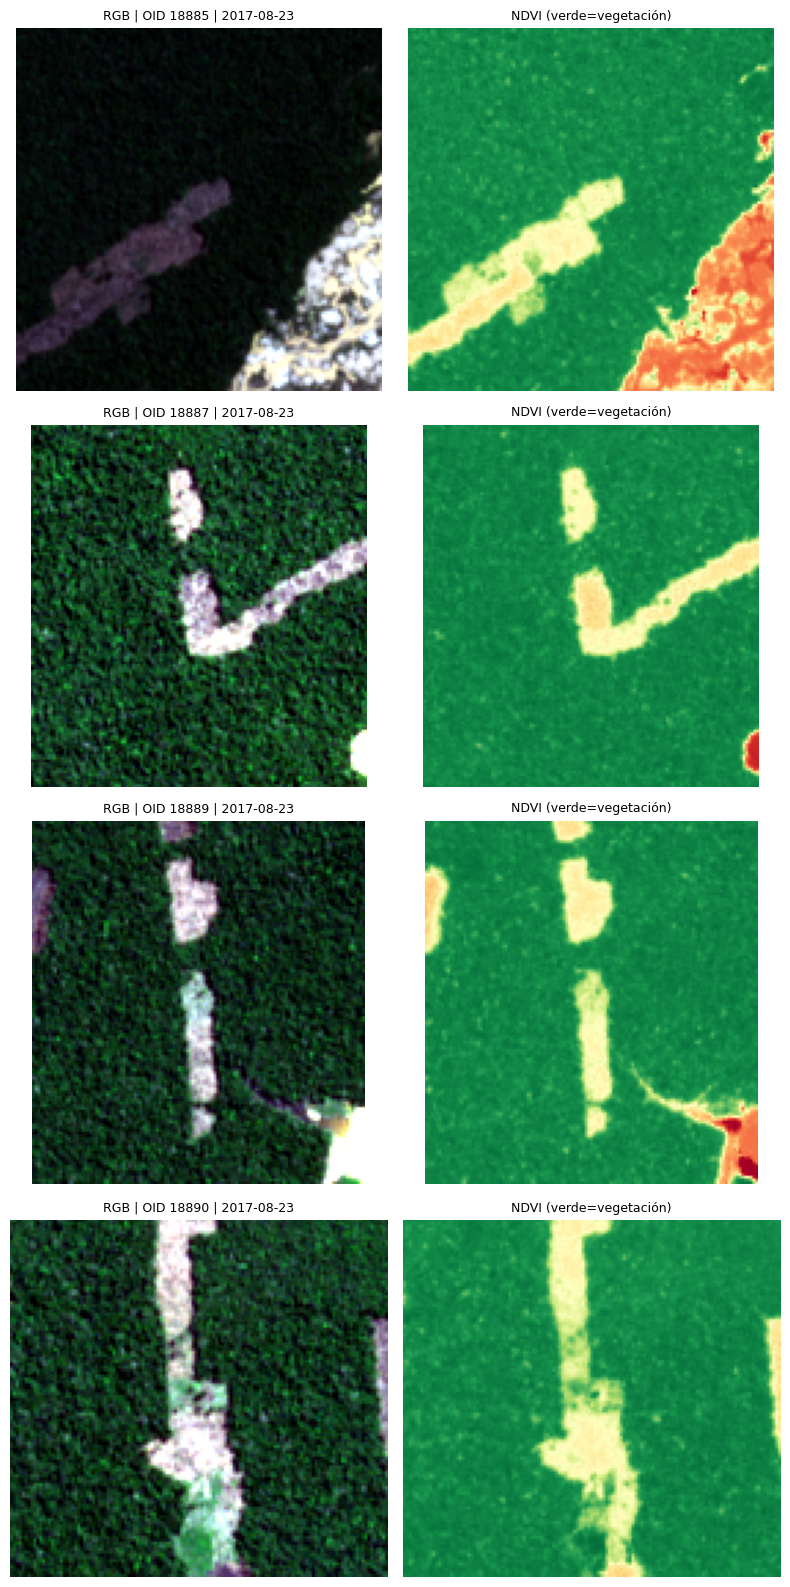

In [16]:
import matplotlib.pyplot as plt

def stretch(a, lo=2, hi=98):
    a = a.astype("float32"); pl, ph = np.percentile(a, [lo, hi])
    return np.clip((a - pl) / (ph - pl + 1e-6), 0, 1)

# solo .tif de 4 bandas (descarta RGB viejos de 3 bandas)
oks = [r for r in load_manifest().values()
       if r.get("status") == "ok" and is_valid_tif(r.get("path"))][:4]
if oks:
    fig, axes = plt.subplots(len(oks), 2, figsize=(8, 4 * len(oks)))
    axes = np.atleast_2d(axes)
    for ax_row, rec in zip(axes, oks):
        with rasterio.open(rec["path"]) as src:
            arr = src.read().astype("float32")   # (4, H, W): R,G,B,NIR
        rgb = np.dstack([stretch(arr[i]) for i in range(3)])
        R, N = arr[0], arr[3]
        ndvi = (N - R) / (N + R + 1e-6)
        ax_row[0].imshow(rgb); ax_row[0].set_title(f"RGB | OID {rec['objectid']} | {rec['datetime']}", fontsize=9)
        im = ax_row[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
        ax_row[1].set_title("NDVI (verde=vegetación)", fontsize=9)
        for a in ax_row: a.axis("off")
    plt.tight_layout(); plt.savefig(str(DATA_DIR / "sentinel_rgbn_muestra.png"), dpi=110, bbox_inches="tight"); plt.show()
else:
    print("Aún no hay descargas ok de 4 bandas en el manifest.")

## 7. Notas para el entrenamiento

- Cada GeoTIFF tiene 4 bandas (R, G, B, NIR) con CRS/transform reales → listo para recortar parches 256×256 (`04_dataset_parches.ipynb`).
- En Colab, antes de entrenar copia `sentinel_rgbn/` de Drive a `/content` (lectura local rápida); no leas miles de parches directo de Drive.
- Para re-descargar un polígono marcado `no_scene` o `error`, bórralo del manifest y vuelve a correr la celda de descarga.
- Polígonos anteriores a ~2018 pueden no tener escena en el archivo COG → quedan `no_scene`. Es esperado.